In [1]:
#Imports e seed
import pandas as pd
import numpy as np
import sys
import ast

from sklearn.neighbors import NearestNeighbors

sys.path.append('..')
from src.evaluation import precision_at_k, catalog_coverage

SEED = 42
np.random.seed(SEED)

In [2]:
# X_matrix está em .npz — precisa extrair o array interno
X_npz = np.load('../data/processed/X_matrix.npz')
X     = X_npz[X_npz.files[0]]  # pega o primeiro (e único) array de dentro

# índices estão em .npy normais — carregamento direto
train_idx = np.load('../data/processed/train_idx.npy', allow_pickle=True)
test_idx  = np.load('../data/processed/test_idx.npy',  allow_pickle=True)

df = pd.read_parquet('../data/processed/books_clean.parquet')
df['genre_list'] = df['genre_list'].apply(
    lambda x: list(x) if not isinstance(x, list) else x
)

X_train = X[train_idx]

print(f"X shape: {X.shape}")
print(f"Treino: {len(train_idx)} | Teste: {len(test_idx)}")

X shape: (84054, 1182)
Treino: 67243 | Teste: 16811


In [3]:
from sklearn.neighbors import NearestNeighbors
from src.evaluation import (
    precision_at_k,
    catalog_coverage
)

sample_test = np.random.choice(
    test_idx,
    300,
    replace=False
)

resultados = []

for k_viz in [5, 10, 20]:

    for metrica in ['cosine', 'euclidean']:

        print(f"\nRodando K={k_viz} | Métrica={metrica}")

        modelo = NearestNeighbors(
            n_neighbors=k_viz + 1,
            metric=metrica,
            algorithm='brute'
        )

        modelo.fit(X[train_idx])

        p10 = precision_at_k(
            modelo=modelo,
            X=X,
            df=df,
            test_idx=sample_test,
            train_idx=train_idx
        )

        cov = catalog_coverage(
            modelo=modelo,
            X=X,
            n_queries=30,
            train_idx=train_idx
        )

        resultados.append({
            'algoritmo': 'KNN',
            'k': k_viz,
            'metrica': metrica,
            'precision@10': round(p10, 4),
            'coverage': round(cov, 4)
        })

        print(
            f"Precision@10={p10:.4f} | "
            f"Coverage={cov:.4f}"
        )

resultados_df = pd.DataFrame(resultados)

display(resultados_df)


Rodando K=5 | Métrica=cosine
Precision@10=1.0000 | Coverage=0.0018

Rodando K=5 | Métrica=euclidean
Precision@10=0.9993 | Coverage=0.0018

Rodando K=10 | Métrica=cosine
Precision@10=1.0000 | Coverage=0.0036

Rodando K=10 | Métrica=euclidean
Precision@10=0.9980 | Coverage=0.0036

Rodando K=20 | Métrica=cosine
Precision@10=1.0000 | Coverage=0.0071

Rodando K=20 | Métrica=euclidean
Precision@10=0.9958 | Coverage=0.0071


,algoritmo,k,metrica,precision@10,coverage
0,KNN,5,cosine,1.0000,0.0018
1,KNN,5,euclidean,0.9993,0.0018
2,KNN,10,cosine,1.0000,0.0036
3,KNN,10,euclidean,0.9980,0.0036
4,KNN,20,cosine,1.0000,0.0071
5,KNN,20,euclidean,0.9958,0.0071


In [4]:
#Registro e exibição
resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values('precision@10', ascending=False)
display(resultados_df)

,algoritmo,k,metrica,precision@10,coverage
0,KNN,5,cosine,1.0000,0.0018
2,KNN,10,cosine,1.0000,0.0036
4,KNN,20,cosine,1.0000,0.0071
1,KNN,5,euclidean,0.9993,0.0018
3,KNN,10,euclidean,0.9980,0.0036
5,KNN,20,euclidean,0.9958,0.0071


In [5]:
#Melhor configuração
melhor = resultados_df.iloc[0]
print(f"Melhor KNN: k={melhor['k']} | metrica={melhor['metrica']}")
print(f"Precision@10 = {melhor['precision@10']:.4f}")
print(f"Coverage     = {melhor['coverage']:.4f}")

Melhor KNN: k=5 | metrica=cosine
Precision@10 = 1.0000
Coverage     = 0.0018


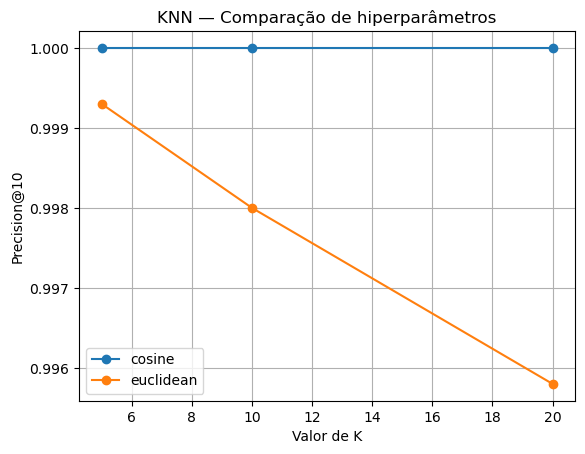

In [6]:
#Gráfico
import matplotlib.pyplot as plt

for metrica in ['cosine', 'euclidean']:
    subset = resultados_df[resultados_df['metrica'] == metrica].sort_values('k')
    plt.plot(subset['k'], subset['precision@10'], marker='o', label=metrica)

plt.xlabel('Valor de K')
plt.ylabel('Precision@10')
plt.title('KNN — Comparação de hiperparâmetros')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
#Salvar resultados para consolidação
resultados_df.to_csv('../data/processed/resultados_knn.csv', index=False)